## IMPORTS

In [80]:
import math
import random
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [2]:
def set_seed(seed=42):
  random.seed(seed)
  torch.manual_seed(seed)

set_seed(42)
device = "cpu"
if torch.cuda.is_available():
  device = "cuda"

print(device)

cuda


## CHAIN GENERATION

We are trying to use protein-inspired structures, so we will try to generate helices, sheets and coils and then stitch them together.

### Helper functions

The ```normalize``` function converts vectors to unit vectors. Unit vectors help when we want a direction without caring about magnitude like making step directions unit lengtj or keeping coil motion stable. If the vector is extremely small or zero, dividing by its norm would explode or become undefined. So, we clamp the norm from below by ```eps```. ```dim=-1``` helps us work on the $xyz$ coordinates and ```keepdim=True``` keeps that dimension as $1$ instead of removing to help with broadcasting.

In [3]:
def normalize(v, eps=1e-8):
  return v / v.norm(dim=-1, keepdim=True).clamp_min(eps)

The ```rescale_steps_to_bond_length``` function takes a chain of points and forces every consecutive step to have the same length, approximately the desired bond length. It takes the vectors from residue $i$ to residue $i+1$ and normalizes each step and scales it to the bond length and rebuilds the chain. This function helps preserve the local direction pattern of the shape but makes the bond lengths uniform so that the motifs are more backbone-like and easier to compare.

In [4]:
def rescale_steps_to_bond_length(coords, bond_len=1.0):
  steps = coords[1:] - coords[:-1]
  # each row of steps is displacement vector from one residue to next
  steps = normalize(steps) * bond_len
  new_coords = [torch.zeros(3, dtype=coords.dtype, device=coords.device)]
  for s in steps:
    new_coords.append(new_coords[-1]+s)

  return torch.stack(new_coords, dim=0)

The ```random_rotation_matrix``` function creates a random 3D rotation matrix. A valid rotation matrix must have orthonormal columns (columns are perpendicular unit vectors) and must have determinant $+1$. If determinant is $-1$, it includes a reflection. Flipping one column changes determinant to $+1$, giving a proper rotation. We get the orthonormal column matrix through QR decomposition. A protein-like chain should not depend on whether it points up, sideways or diagonaly. This helper function helps us randomly rotate structures for augmentation/visualization.

In [5]:
def random_rotation_matrix(dtype=torch.float32, device="cpu"):
  A = torch.randn(3, 3, dtype=dtype, device=device)
  Q, R = torch.linalg.qr(A)
  if torch.det(Q) < 0:
    Q[:, 0] = -Q[:, 0]

  return Q

The ```apply_random_se3``` function applies a random rigid motion to the chain (SE(3) transform). This function helps with augmentation and is useful because the same chain should still be the same structure after rotation/translation. So this function changes position/orientation in space but preserves distances, angles and shape. In math, rotation is usually defined as $R.x$ where $x$ is column vector but since here coords is a row vector, we use transpose of $R$ to get an equivalent transposed matrix within the same math definition.

In [6]:
def apply_random_se3(coords, rotate=True, translate=True):
  out = coords.clone()
  if rotate == True:
    R = random_rotation_matrix(dtype=out.dtype, device=out.device)
    out = out @ R.T
  if translate == True:
    t = torch.randn(1, 3, dtype=out.dtype, device=out.device)
    out = out + t

  return out

The ```bond_lengths``` function computes the distance between each consecutive pair of points. Mainly used for sanity check.

In [7]:
def bond_lengths(coords):
  return (coords[1:] - coords[:-1]).norm(dim=-1)

The ```plot_chain_3d``` function helps generate a 3D plot.

In [8]:
def plot_chain_3d(coords, title="chain", ax=None):
  c = coords.detach().cpu()
  x, y, z = c[:, 0], c[:, 1], c[:, 2]

  if ax is None:
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection="3d")

  ax.plot(x, y, z, linewidth=2, marker="o", markersize=3)
  ax.scatter(x[0], y[0], z[0], s=60, marker="o", label="start")
  ax.scatter(x[-1], y[-1], z[-1], s=60, marker="^", label="end")
  ax.set_title(title)
  ax.legend()

  eps=1e-3
  xspan = max((x.max()-x.min()).item(), eps)
  yspan = max((y.max()-y.min()).item(), eps)
  zspan = max((z.max()-z.min()).item(), eps)
  ax.set_box_aspect((xspan, yspan, zspan))

  ax.view_init(elev=20, azim=-60)
  # azim = azimuth, horizontal rotation around the plot
  return ax

### Helix generator

A standard 3D helix can be written as
$$r(\theta) = \begin{bmatrix} r\cos\theta \\ r\sin\theta \\ c\theta \end{bmatrix}$$
where $r$ is the radius of the helix, $\theta$ is the angular parameter and $c$ controls how fast the helix rises in $z$ as it turns. So, this traces a spiral around the $z-$axis.

$n_{turn}$ is residues per turn which controls how many discrete points are needed to complete one full $2\pi$ revolution. If $n_{turn}$ is smaller, angle changes faster and helix winds more tightly whereas if it is larger, angle changes more slowly and helix winds more gently. Each step advances the angle by $\frac{2\pi}{n_{turn}}.$

$h$ controls how much the helix moves upward in $z$ when we go from point $i$ to $i+1$. We use ```rescale_steps_to_bond_length``` because the step length though constant, is not necessarily equal to the desired bond length. We do it to ensure that the final chain preserves the local direction pattern of the helix but every step has exactly length $b$.

Also, for $z_i = hi$:
$$\theta_i = \frac{2\pi i}{n_{turn}}$$

$$i = \frac{n_{turn}}{2\pi}\theta_i$$

$$z_i = h \cdot \frac{n_{turn}}{2\pi}\theta_i \equiv c\theta_i$$

In [9]:
def make_helix(
    L,
    radius=1.0,
    rise_per_res=0.6,
    residues_per_turn=3.6,
    bond_len=1.0,
    device="cpu"
):
  i = torch.arange(L, dtype=torch.float32, device=device)
  theta = 2 * math.pi * i / residues_per_turn

  x = radius * torch.cos(theta)
  y = radius * torch.sin(theta)
  z = rise_per_res * i

  coords = torch.stack([x, y, z], dim=-1)
  coords = rescale_steps_to_bond_length(coords, bond_len=bond_len)

  return coords

In [10]:
helix = make_helix(
    L=64,
    radius=2,
    rise_per_res=0.25,
    residues_per_turn=10,
    bond_len=1.0,
    device=device
)

In [11]:
print(helix.shape)

torch.Size([64, 3])


<Axes3D: title={'center': 'Helix'}>

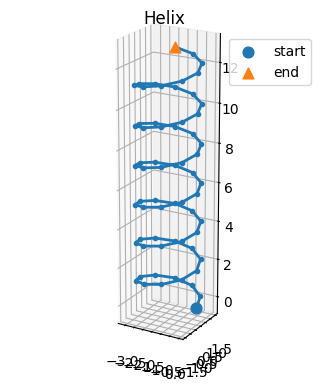

In [12]:
fig = plt.figure(figsize=(15, 4))
ax1 = fig.add_subplot(131, projection="3d")
plot_chain_3d(helix, "Helix", ax=ax1)

### Strand generator

We move the chain steadily in the $x-$axis i.e. each residue advances by a constant amount in the forward direction. We use the $y$ coordinate to make the chain alternate left-right-left-right to create the zig-zag. The $z$ coordinate helps with the zig-zag above and below the plane ```rescale_steps_to_bond_length``` is once again used to ensure final chain has the same zig-zag directions but every step has the exact bond length.

In [13]:
def make_strand(
    L,
    zigzag_const=1.0,
    z_const=0.5,
    forward_step=0.5,
    bond_len=1.0,
    device="cpu"
):
  i = torch.arange(L, dtype=torch.float32, device=device)

  x = forward_step * i
  y = zigzag_const * ((-1.0) ** i)
  z = z_const * ((-1.0)**(i+1))

  coords = torch.stack([x, y, z], dim=-1)
  coords = rescale_steps_to_bond_length(coords, bond_len=bond_len)

  return coords

In [14]:
strand = make_strand(
    L = 64,
    bond_len=1.0,
    device=device
)

In [15]:
print(strand.shape)

torch.Size([64, 3])


<Axes3D: title={'center': 'Strand'}>

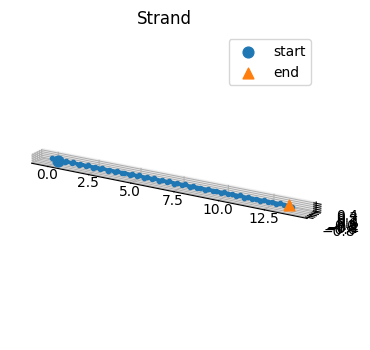

In [16]:
fig = plt.figure(figsize=(15,4))
ax2 = fig.add_subplot(132, projection="3d")
plot_chain_3d(strand, "Strand", ax=ax2)

### Coil generator

A coil here is a stochastic chain, each new bond direction is a small random perturbation of the previous one. First point is placed at the origin and then we sample a random initial direction using gaussian and generate a corresponding random unit vector. Then at each step, sample Gaussian noise, scale it by ```turn_strength``` and add it to the current direction and normalize it to the get the unit vector in the new direction. Now, just move one bond length in that direction.

A helix is determined and structured whereas coil is stochastic and irregular.

In [17]:
def make_coil(
    L,
    turn_strength=0.35,
    bond_len=1.0,
    device="cpu"
):
  coords = [torch.zeros(3, dtype=torch.float32, device=device)]
  direction = torch.randn(3, device=device)
  direction = direction / direction.norm()

  for _ in range(L-1):
    noise = turn_strength * torch.randn(3, device=device)
    direction = direction + noise
    direction = direction / direction.norm()
    next_pt = coords[-1] + bond_len * direction
    coords.append(next_pt)

  return torch.stack(coords, dim=0)

In [18]:
coil = make_coil(
    L=64,
    bond_len=1.0,
    device=device
)

In [19]:
print(coil.shape)

torch.Size([64, 3])


<Axes3D: title={'center': 'Coil'}>

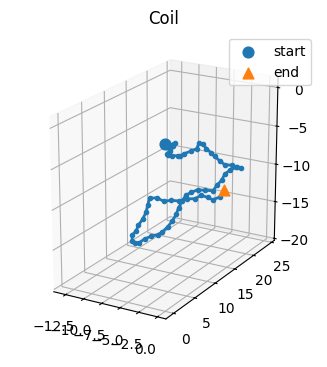

In [20]:
fig = plt.figure(figsize=(15, 4))
ax3 = fig.add_subplot(133, projection="3d")
plot_chain_3d(coil, "Coil", ax=ax3)

### SE(3) test

Checking that the object is a 3D shape and not tied to one absolute orientation.

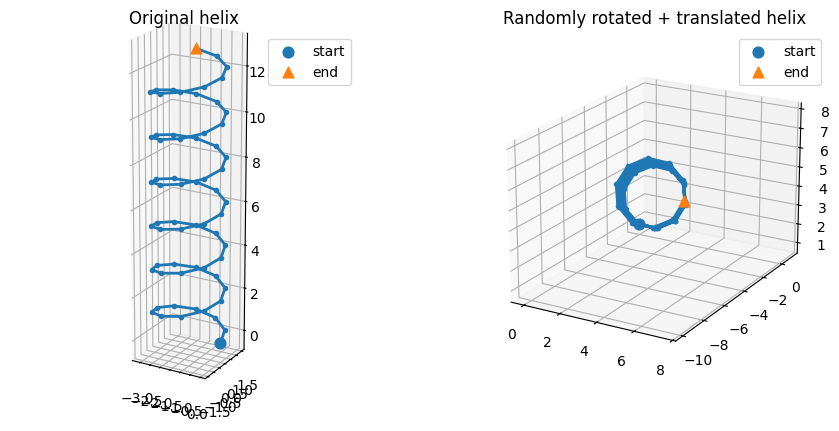

In [21]:
helix_augmentation = apply_random_se3(helix)
fig = plt.figure(figsize=(10, 4))

ax1 = fig.add_subplot(121, projection="3d")
plot_chain_3d(helix, "Original helix", ax=ax1)

ax2 = fig.add_subplot(122, projection="3d")
plot_chain_3d(helix_augmentation, "Randomly rotated + translated helix", ax=ax2)

plt.tight_layout()
plt.show()

### Motif wrapper function

In [22]:
MOTIF_TO_ID = {"helix": 0, "strand": 1, "coil": 2}
ID_TO_MOTIF = {0: "helix", 1: "strand", 2: "coil"}

def generate_motif(kind, L, bond_len=1.0, device="cpu", **kwargs):
  if kind == "helix":
    return make_helix(L=L, bond_len=bond_len, device=device, **kwargs)
  elif kind == "strand":
    return make_strand(L=L, bond_len=bond_len, device=device, **kwargs)
  elif kind == "coil":
    return make_coil(L=L, bond_len=bond_len, device=device, **kwargs)
  else:
    raise ValueError(f"Unknown motif kind: {kind}")

### Stitch segments

Stitching multiple motifs together to form one protein chain. Seam point is the point where two motifs are stitched together. In other words, the end point of the previous motif must be the same as the start point of the current motif. So, for all motifs except for the first one we need one extra anchor point so that after dropping the duplicated seam point, they still contribute the same number of residues. We can add random rotation to each motif to ensure that all the motifs are not in the same canonical orientation. We first shift each segment so that its start point is the origin and if the segment is not the first segment then we place it at the last point of the previous segment.

In [23]:
def stitch_segments(specs, bond_len=1.0, random_orient=True, device="cpu"):
  coords_parts = []
  label_parts = []
  segid_parts = []

  prev_end = None

  for seg_id, spec in enumerate(specs):
    kind = spec["kind"]
    contrib_len = spec["length"]
    kwargs = spec.get("kwargs", {})

    raw_len = 0
    if seg_id == 0:
      raw_len = contrib_len
    else:
      raw_len = contrib_len + 1

    seg = generate_motif(
        kind=kind,
        L=raw_len,
        bond_len=bond_len,
        device=device,
        **kwargs
    )

    if random_orient:
      R = random_rotation_matrix(dtype=seg.dtype, device=seg.device)
      seg = seg @ R.T

    seg = seg - seg[0:1]

    if seg_id == 0:
      placed = seg
    else:
      seg = seg + prev_end.unsqueeze(0)
      # .unsqueeze(0) adds a dimension of size 1 at position 0
      # so that i can broadcast when added to seg of shape (L, 3)
      placed = seg[1:]

    coords_parts.append(placed)
    label_parts.append(torch.full((placed.shape[0],), MOTIF_TO_ID[kind], dtype=torch.long, device=device))
    segid_parts.append(torch.full((placed.shape[0],), seg_id, dtype=torch.long, device=device))

    prev_end = placed[-1]

  coords = torch.cat(coords_parts, dim=0)
  labels = torch.cat(label_parts, dim=0) # motif id per residue
  seg_ids = torch.cat(segid_parts, dim=0) # segment id per residue

  return coords, labels, seg_ids

### Chain plotting helper

In [24]:
def plot_full_3d_chain(coords, labels, title="composed chain", ax=None):
  coords = coords.detach().cpu()
  labels = labels.detach().cpu()

  x = coords[:, 0]
  y = coords[:, 1]
  z = coords[:, 2]

  if ax is None:
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")

  ax.plot(x, y, z, color="black", linewidth=1.0, alpha=0.7)

  colors = {
      0: "tab:blue", #helix
      1: "tab:orange", #strand
      2: "tab:green", #coil
  }
  #tab: ---> from tableau color palette looks nice

  for motif_id, motif_name in ID_TO_MOTIF.items():
    mask = (labels == motif_id)
    # creates boolean tensor where values are true wherever
    # residue type is motif type
    if mask.any(): # checks if any residues are of that type, otherwise skips
      ax.scatter(
          x[mask],
          y[mask],
          z[mask],
          s=14,
          color=colors[motif_id],
          label=motif_name
      )

      # x[mask], y[mask], z[mask] adds only coordinates where
      # mask is true

  ax.scatter(x[0], y[0], z[0], s=60, marker="o", color="red", label="start")
  ax.scatter(x[-1], y[-1], z[-1], s=60, marker="^", color="purple", label="end")

  ax.set_title(title)
  ax.legend()

  eps=1e-3
  xspan = max((x.max() - x.min()).item(), eps)
  yspan = max((y.max() - y.min()).item(), eps)
  zspan = max((z.max() - z.min()).item(), eps)
  ax.set_box_aspect((xspan, yspan, zspan))
  ax.view_init(elev=20, azim=-60)

  return ax


#### testing with a L=64 fixed chain

In [25]:
specs = [
    {
        "kind": "helix",
        "length": 20,
        "kwargs": {
            "radius": 1.0,
            "rise_per_res": 0.25,
            "residues_per_turn": 5
        },
    },
    {
        "kind": "strand",
        "length": 20,
        "kwargs": {
            "zigzag_const": 1.0,
            "z_const": 0.5,
            "forward_step": 0.5
        },
    },
    {
        "kind": "coil",
        "length": 24,
        "kwargs": {
            "turn_strength": 0.35
        },
    },
]

coords, labels, seg_ids = stitch_segments(
    specs,
    bond_len=1.0,
    random_orient=True,
    device=device
)

In [26]:
print(coords.shape)

torch.Size([64, 3])


In [27]:
print(labels.shape)

torch.Size([64])


In [28]:
print(seg_ids.shape)

torch.Size([64])


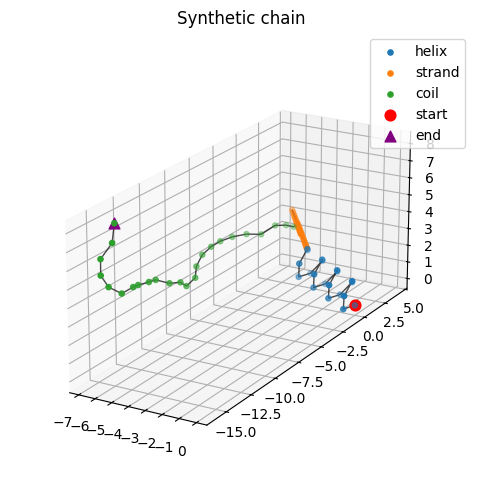

In [29]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
_ = plot_full_3d_chain(coords, labels, title="Synthetic chain", ax=ax)
plt.show()

### FULL CHAIN GENERATOR

The ```sample_segment_lengths``` function returns a list of ```n_segments``` positive lengths that sum exactly to a given total length with each length lying in a range of min length and max length.

In [30]:
def sample_segment_lengths(
    total_len,
    n_segments,
    min_len=12,
    max_len=24
):
  if total_len < n_segments * min_len:
    raise ValueError("total_len too small for chosen n_segments and min_len")
  if total_len > n_segments * max_len:
    raise ValueError("total_len too large for chosen n_segments and max_len")

  lengths = [min_len] * n_segments
  remaining = total_len - (n_segments * min_len)
  capacities = [max_len - min_len] * n_segments

  while remaining > 0:
    valid_idxs = [i for i in range(n_segments) if capacities[i]>0]
    j = random.choice(valid_idxs)
    lengths[j] += 1
    capacities[j] -= 1
    remaining -= 1

  return lengths

The ```sample_motif_kinds``` returns a list of ```n_segments``` motif kinds.

In [31]:
def sample_motif_kinds(n_segments, motif_names=("helix", "strand", "coil")):
  kinds = []
  prev = None # avoiding consecutive duplicate motif types for now

  for _ in range(n_segments):
    choices = [m for m in motif_names if m!=prev]
    kind = random.choice(choices)
    kinds.append(kind)
    prev = kind

  return kinds

The ```sample_motif_kwargs``` function generates the kwargs for each ```make_<shape>``` function randomly.

In [32]:
def sample_motif_kwargs(kind):
  if kind == "helix":
    return {
        "radius": random.uniform(1.5, 2.2),
        "rise_per_res": random.uniform(0.20, 0.35),
        "residues_per_turn": random.uniform(8.0, 12.0)
    }
  elif kind == "strand":
    return {
        "zigzag_const": random.uniform(0.8, 1.2),
        "z_const": random.uniform(0.3, 0.7),
        "forward_step": random.uniform(0.4, 0.7)
    }
  elif kind == "coil":
    return {
        "turn_strength": random.uniform(0.20, 0.45)
    }
  else:
    raise ValueError(f"Unknown motif kind: {kind}")

The ```sample_random_specs``` function combines all the random functions to build a random valid spec list.

In [33]:
def sample_random_specs(
    total_len=64,
    min_segments=3,
    max_segments=5,
    min_len=12,
    max_len=24
):
  feasible_segment_counts = []
  for n in range(min_segments, max_segments+1):
    if n*min_len <= total_len and total_len <= n*max_len:
      feasible_segment_counts.append(n)

  if not feasible_segment_counts:
    raise ValueError("No feasible number of segments for these constraints")

  n_segments = random.choice(feasible_segment_counts)
  lengths = sample_segment_lengths(
      total_len=total_len,
      n_segments=n_segments,
      min_len=min_len,
      max_len=max_len
  )
  kinds = sample_motif_kinds(n_segments)

  specs = []
  for kind, length in zip(kinds, lengths):
    specs.append({
        "kind": kind,
        "length": length,
        "kwargs": sample_motif_kwargs(kind),
    })

  return specs

In [34]:
specs = sample_random_specs(
    total_len=64,
    min_segments=3,
    max_segments=5,
    min_len=12,
    max_len=24
)

print("Random specs:")
for s in specs:
  print(s["kind"], s["length"], s["kwargs"])

print("Total length:", sum(s["length"] for s in specs))

Random specs:
helix 14 {'radius': 1.5222478756372486, 'rise_per_res': 0.21405428597923887, 'residues_per_turn': 8.930643573562959}
strand 13 {'zigzag_const': 1.040807491619992, 'z_const': 0.5244980251754452, 'forward_step': 0.614805883876721}
helix 13 {'radius': 1.9909274815131652, 'rise_per_res': 0.2629279731442488, 'residues_per_turn': 9.796836185135415}
strand 12 {'zigzag_const': 0.9112762832922651, 'z_const': 0.6477201283171735, 'forward_step': 0.6276422101389302}
coil 12 {'turn_strength': 0.23991482909422254}
Total length: 64


In [35]:
coords, labels, seg_ids = stitch_segments(
    specs,
    bond_len=1.0,
    random_orient=True,
    device=device
)

In [36]:
print(coords.shape)

torch.Size([64, 3])


In [37]:
print(labels.shape)

torch.Size([64])


In [38]:
print(seg_ids.shape)

torch.Size([64])


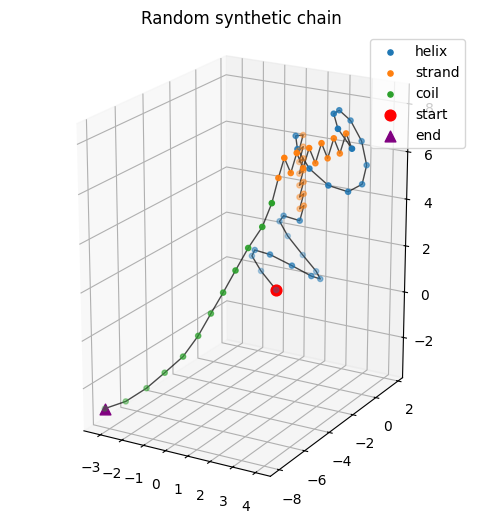

In [39]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
_ = plot_full_3d_chain(coords, labels, title="Random synthetic chain", ax=ax)
plt.show()

## GEOMETRY

Let the chain be $x_0, x_1, ..., x_{L-1} \in \mathbb{R}^3$

Bond vectors are $b_i = x_{i+1} - x_{i}$ where $i=0, ..., L-2$. These are the step vectors along the chain.

In [40]:
def bond_vectors(coords):
  return coords[1:] - coords[:-1]

Unit tangents are normalized bond directions.  
$$t_i = \frac{b_i}{||b_i||}$$

In [41]:
def unit_tangents(coords, eps=1e-8):
  b = bond_vectors(coords)
  return b / b.norm(dim=-1, keepdim=True).clamp_min(eps)

Contour length is the total chain length.

In [42]:
def contour_length(coords):
  return (coords[1:] - coords[:-1]).norm(dim=-1).sum()

We can calculate the distance from the first residue to the last residue.

In [43]:
def end_to_end_distance(coords):
  return (coords[-1] - coords[0]).norm()

Global extension ratio is a scalar in $[0, 1]$ that compares the distance from the first to last residue to the overall chain length. If the ratio is near $1$ then the interpretation is that the chain is very extended/straight and if it is smaller then it means that the chain is more curled up.  
$$extension(x) = \frac{||x_{L-1} - x_0||}{\sum_{i=0}^{L-2}||b_i||}$$

In [44]:
def extension_ratio(coords, eps=1e-8):
  return end_to_end_distance(coords) / contour_length(coords).clamp_min(eps)
  # clamp to prevent division by 0 though highly unlikely

### checks

In [45]:
L = 64

In [46]:
helix = make_helix(
    L=L,
    radius=2.0,
    rise_per_res=0.25,
    residues_per_turn=10,
    bond_len=1.0,
    device=device
)

In [47]:
strand = make_strand(
    L=L,
    zigzag_const=1.0,
    z_const=0.5,
    forward_step=0.5,
    bond_len=1.0,
    device=device
)

In [48]:
coil = make_coil(
    L=L,
    turn_strength=0.35,
    bond_len=1.0,
    device=device
)

In [49]:
for name, coords in [("helix", helix), ("strand", strand), ("coil", coil)]:
  b = bond_vectors(coords)
  t = unit_tangents(coords)
  ext = extension_ratio(coords)

  print(f"{name}")
  print("coords shape: ", coords.shape)
  print("bonds shape: ", b.shape)
  print("tangents shape: ", t.shape)
  print("extension: ", ext.item())
  print()

helix
coords shape:  torch.Size([64, 3])
bonds shape:  torch.Size([63, 3])
tangents shape:  torch.Size([63, 3])
extension:  0.20238138735294342

strand
coords shape:  torch.Size([64, 3])
bonds shape:  torch.Size([63, 3])
tangents shape:  torch.Size([63, 3])
extension:  0.2187669724225998

coil
coords shape:  torch.Size([64, 3])
bonds shape:  torch.Size([63, 3])
tangents shape:  torch.Size([63, 3])
extension:  0.24405862390995026



In [50]:
for name, coords in [("helix", helix), ("strand", strand), ("coil", coil)]:
  t = unit_tangents(coords)
  tnorm = t.norm(dim=-1)
  print(f"tangent norm mean = {tnorm.mean().item():.6f}")
  print(f"tangent norm std = {tnorm.std().item():.6f}")

tangent norm mean = 1.000000
tangent norm std = 0.000000
tangent norm mean = 1.000000
tangent norm std = 0.000000
tangent norm mean = 1.000000
tangent norm std = 0.000000


In [51]:
for name, coords in [("helix", helix), ("strand", strand), ("coil", coil)]:
  print(f"{name:} extension ratio = {extension_ratio(coords).item():.6f}")

helix extension ratio = 0.202381
strand extension ratio = 0.218767
coil extension ratio = 0.244059


In [52]:
specs = sample_random_specs(
    total_len=64,
    min_segments=3,
    max_segments=5,
    min_len=12,
    max_len=24
)

coords, labels, seg_ids = stitch_segments(
    specs,
    bond_len=1.0,
    random_orient=True,
    device=device
)

b = bond_vectors(coords)
t = unit_tangents(coords)
ext = extension_ratio(coords)

print("random chain")
print("coords shape: ", coords.shape)
print("bonds shape: ", b.shape)
print("tangents shape: ", t.shape)
print("extension: ", ext.item())

random chain
coords shape:  torch.Size([64, 3])
bonds shape:  torch.Size([63, 3])
tangents shape:  torch.Size([63, 3])
extension:  0.1327040195465088


## DATASET + DATALOADER

For training a diffusion model, it helps if each chain is centered (centered means chain's center of mass sits at the origin). This removes global translation which we do not want the model to waste capacity on.

In [53]:
def center_coords(coords):
  return coords - coords.mean(dim=0, keepdim=True)
  # done for each input example
  # dim = 0 to average across every residue in the chain

### Dataset class

```device="cpu"``` here so that the dataset creates CPU tensors and moves batches to GPU later during training.

In [54]:
class SyntheticChainDataset(Dataset):
  def __init__(
      self,
      num_samples,
      total_len=64,
      bond_len=1.0,
      min_segments=3,
      max_segments=5,
      min_len=12,
      max_len=24,
      random_orient=True,
      center=True,
      device="cpu"
  ):
    self.num_samples = num_samples
    self.total_len = total_len
    self.bond_len = bond_len
    self.min_segments = min_segments
    self.max_segments = max_segments
    self.min_len = min_len
    self.max_len = max_len
    self.random_orient = random_orient
    self.center = center
    self.device = device

  def __len__(self):
    return self.num_samples

  def __getitem__(self, idx):
    specs = sample_random_specs(
        total_len = self.total_len,
        min_segments = self.min_segments,
        max_segments = self.max_segments,
        min_len = self.min_len,
        max_len = self.max_len
    )

    coords, labels, seg_ids = stitch_segments(
        specs,
        bond_len = self.bond_len,
        random_orient = self.random_orient,
        device = self.device
    )

    if self.center == True:
      coords = center_coords(coords)

    return {
        "coords" : coords, # (L, 3)
        "labels": labels, # (L,)
        "seg_ids": seg_ids # (L,)
    }

In [55]:
train_ds = SyntheticChainDataset(
    num_samples = 2000,
    total_len = 64,
    bond_len = 1.0,
    min_segments = 3,
    max_segments = 5,
    min_len = 12,
    max_len = 24,
    random_orient = True,
    center = True,
    device = "cpu"
)

In [56]:
print(len(train_ds))

2000


In [57]:
sample = train_ds[0] # calls train_ds.__getitem__(0)
print(sample.keys())
print(sample["coords"].shape)
print(sample["labels"].shape)
print(sample["seg_ids"].shape)

dict_keys(['coords', 'labels', 'seg_ids'])
torch.Size([64, 3])
torch.Size([64])
torch.Size([64])


In [58]:
coords = sample["coords"]
labels = sample["labels"]
seg_ids = sample["seg_ids"]

print(torch.isfinite(coords).all().item())
print(labels.dtype)
print(seg_ids.dtype)
print(coords.mean(dim=0))
print(bond_lengths(coords).mean().item())
print(bond_lengths(coords).std().mean())

True
torch.int64
torch.int64
tensor([-1.1921e-07,  6.7055e-08,  5.2154e-08])
1.0
tensor(3.7811e-07)


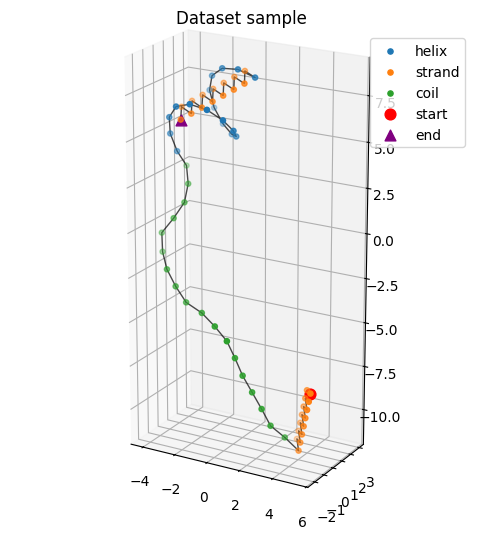

In [59]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")
_ = plot_full_3d_chain(
    sample["coords"],
    sample["labels"],
    title="Dataset sample",
    ax=ax
)
plt.show()

### Dataloader

```drop_last=True``` ensures that each batch has the same number of samples and in case the last batch has less than batch size number of samples, it will drop that batch. This is done because inconsistent batch size can cause problems with operations like BatchNorm that require the batch dimensions to be uniform.

In [60]:
train_loader = DataLoader(
    train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

batch = next(iter(train_loader))
print(batch["coords"].shape)
print(batch["labels"].shape)
print(batch["seg_ids"].shape)

torch.Size([16, 64, 3])
torch.Size([16, 64])
torch.Size([16, 64])


In [61]:
coords_b = batch["coords"]
labels_b = batch["labels"]
seg_ids_b = batch["seg_ids"]

print(torch.isfinite(coords_b).all().item())
print(coords_b.dtype)
print(labels_b.dtype)
print(seg_ids_b.dtype)

batch_means = coords_b.mean(dim=1) # (B, 3)
print(batch_means.abs().mean().item())
# without abs pos and neg values would cancel each other and
# may give a misleading representation of the chain being centered
# by abs we check how far away the centers of the chain are from the origin
# irrespective of the direction

bond_len_batch = (coords_b[:, 1:] - coords_b[:, :-1]).norm(dim=-1) # (B, L-1)
print(bond_len_batch.mean().item())
print(bond_len_batch.std().item())
print(bond_len_batch.min().item())
print(bond_len_batch.max().item())

True
torch.float32
torch.int64
torch.int64
1.815690922057911e-07
1.0
3.3093311913034995e-07
0.9999982714653015
1.0000016689300537


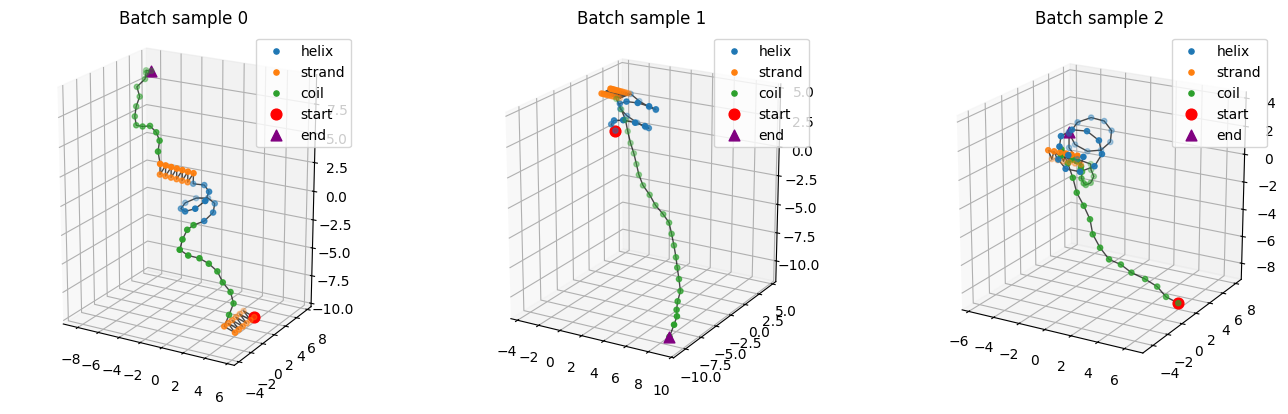

In [62]:
fig = plt.figure(figsize=(14,4))

for i in range(3):
  ax = fig.add_subplot(1, 3, i+1, projection="3d")
  _ = plot_full_3d_chain(
      coords_b[i],
      labels_b[i],
      title=f"Batch sample {i}",
      ax=ax
  )

plt.tight_layout()
plt.show()

## 3D FORWARD DIFFUSION

Standard cosine scheduler from Improved DDPM.

In [64]:
def cosine_schedule(T, s=0.008, device="cpu"):
  steps = torch.arange(T+1, dtype=torch.float32, device=device)
  x = (steps/T + s)/(1 + s)
  f = torch.cos(x * math.pi / 2) ** 2
  alpha_bar_u = f/f[0]

  betas = 1 - (alpha_bar_u[1:]/alpha_bar_u[:-1])
  betas = betas.clamp(1e-8, 0.999)

  alphas = 1 - betas
  alpha_bar = torch.cumprod(alphas, dim=0)

  return betas, alphas, alpha_bar

Broadcasting helper. During broadcasting, PyTorch stretches a smaller tensor to match a larger one during element-wise operations. ```.unsqueeze(i)``` helps in adding a dimension at a specified position i. The ```extract``` helper function below helps in creating size $1$ placeholder dimensions so that broadcasting exists.

In [66]:
def extract(a, t, x_shape):
  out = a[t] # will have same dim as t so (B,)
  while out.ndim < len(x_shape):
    out = out.unsqueeze(-1)

  return out
  # if x_shape = (B, L, 3), this returns shape (B, 1, 1)

Forward noising process.

In [70]:
def q_sample(coords0, t, alpha_bar, eps=None):
  if eps is None:
    eps = torch.randn_like(coords0)

  alpha_bar_t = extract(alpha_bar, t, coords0.shape)
  xt = torch.sqrt(alpha_bar_t)*coords0 + torch.sqrt(1-alpha_bar_t)*eps

  return xt, eps

### checks

In [71]:
T = 1000
betas, alphas, alpha_bar = cosine_schedule(T, device="cpu")

batch = next(iter(train_loader))
coords0 = batch["coords"]

print(coords0.shape)
print(betas.shape)
print(alpha_bar.shape)

torch.Size([16, 64, 3])
torch.Size([1000])
torch.Size([1000])


In [72]:
B = coords0.shape[0]
t = torch.randint(0, T, (B,), dtype=torch.long)

xt, eps = q_sample(coords0, t, alpha_bar)

print(t.shape)
print(xt.shape)
print(eps.shape)
print(torch.isfinite(xt).all().item())
# .all() returns single element tensor, .item() converts to plain python

torch.Size([16])
torch.Size([16, 64, 3])
torch.Size([16, 64, 3])
True


In [73]:
single = coords0[0:1] #(1, L, 3)

t_small = torch.tensor([0], dtype=torch.long)
t_mid = torch.tensor([200], dtype=torch.long)
t_big = torch.tensor([999], dtype=torch.long)

x_small, _ = q_sample(single, t_small, alpha_bar)
x_mid, _ = q_sample(single, t_mid, alpha_bar)
x_big, _ = q_sample(single, t_big, alpha_bar)

print(single.shape)
print(x_small.shape)
print(x_mid.shape)
print(x_big.shape)


torch.Size([1, 64, 3])
torch.Size([1, 64, 3])
torch.Size([1, 64, 3])
torch.Size([1, 64, 3])


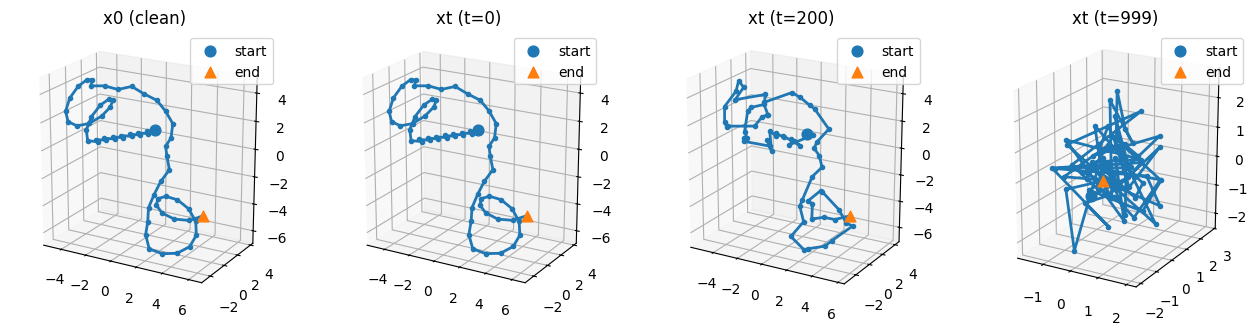

In [74]:
fig = plt.figure(figsize=(16, 4))

ax1 = fig.add_subplot(1, 4, 1, projection="3d")
_ = plot_chain_3d(single[0], title="x0 (clean)", ax=ax1)

ax2 = fig.add_subplot(1, 4, 2, projection="3d")
_ = plot_chain_3d(x_small[0], title="xt (t=0)", ax=ax2)

ax3 = fig.add_subplot(1, 4, 3, projection="3d")
_ = plot_chain_3d(x_mid[0], title="xt (t=200)", ax=ax3)

ax4 = fig.add_subplot(1, 4, 4, projection="3d")
_ = plot_chain_3d(x_big[0], title="xt (t=999)", ax=ax4)


## TIME-CONDITIONING + MINIMAL DENOISER

### Sinusoidal timestep embedding

In [78]:
def time_embedding(t: torch.Tensor, dim=128, max_period=10000):
  t = t.view(-1).float() # (B, )
  half = dim // 2
  freqs = torch.exp(-math.log(max_period)*(torch.arange(0, half, device=t.device).float()/max(half-1, 1)))
  # exp(log(a)*c) = exp(log(a^c))
  args = t.float().unsqueeze(1) * freqs.unsqueeze(0) # (B, half)
  # a column dimension is added to t
  # a row dimension is added to freqs
  embs = torch.cat([torch.cos(args), torch.sin(args)], dim=-1) # (B, 2*half)

  if dim%2==1:
    embs = torch.cat([embs, torch.zeros(embs.shape[0], 1, device=t.device)], dim=1)

  return embs # (B, dim)

In [79]:
B = 4
t = torch.tensor([0, 1, 10, 999], dtype=torch.long)
emb = time_embedding(t, dim=128)

print(t.shape)
print(emb.shape)
print(emb[:2, :8])

torch.Size([4])
torch.Size([4, 128])
tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [0.5403, 0.6494, 0.7341, 0.7991, 0.8487, 0.8863, 0.9147, 0.9361]])


### Minimal denoiser  
We use a noised chain of shape $(B, L, 3)$ and timestep of shape $(B,)$ to predict the noise that was added at that timestep. We use a simple flattened MLP baseline for now to flatten chain from $(B, L, 3)$ to $(B, 3L)$, concatenate timestep embedding, MLP and reshape back to $(B, L, 3).$

In [81]:
class EpsChainMLP(nn.Module):
  def __init__(self, chain_len, time_dim=128, hidden_dim=512):
    super().__init__()
    self.chain_len = chain_len
    self.time_dim = time_dim
    self.input_dim = chain_len * 3

    self.net = nn.Sequential(
        nn.Linear(self.input_dim + time_dim, hidden_dim),
        nn.SiLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.SiLU(),
        nn.Linear(hidden_dim, self.input_dim)
    )

  def forward(self, xt, t):
    B, L, C = xt.shape
    assert L == self.chain_len
    assert C == 3

    x_flat = xt.reshape(B, L*C) # (B, 3L)
    t_emb = time_embedding(t, self.time_dim) # (B, time_dim)

    h = torch.cat([x_flat, t_emb], dim=-1) # now there will be 3*L + tim_dim columns
    output = self.net(h) # (B, 3L)
    eps_hat = output.reshape(B, L, C) # (B, L, 3)

    return eps_hat

### checks

In [82]:
chain_len = 64
model = EpsChainMLP(chain_len=chain_len, time_dim=128, hidden_dim=512)

batch = next(iter(train_loader))
coords0 = batch["coords"] # (B, L, 3)
B = coords0.shape[0]

t = torch.randint(0, T, (B,), dtype=torch.long)
xt, eps = q_sample(coords0, t, alpha_bar)

eps_hat = model(xt, t)

print(coords0.shape)
print(t.shape)
print(xt.shape)
print(eps.shape)
print(eps_hat.shape)
print(torch.isfinite(eps_hat).all().item())

torch.Size([16, 64, 3])
torch.Size([16])
torch.Size([16, 64, 3])
torch.Size([16, 64, 3])
torch.Size([16, 64, 3])
True


In [84]:
loss = ((eps_hat - eps)**2).mean()
print(loss.item())

1.0425225496292114


In [85]:
model.zero_grad()
loss.backward()

max_grad = 0.0
for p in model.parameters():
  if p.grad is not None:
    max_grad = max(max_grad, p.grad.abs().max().item())

print(max_grad)

0.00916585698723793
